# a. Implementation of Libraries

In [ ]:
# Core libraries
import os
import re
import string
import unicodedata
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud, STOPWORDS
from bs4 import BeautifulSoup

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)  # Added for tokenization

# Machine Learning - Scikit Learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                           ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

# XGBoost
from xgboost.sklearn import XGBClassifier

# Deep Learning - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import (Dense, Input, Embedding, LSTM, Dropout,
                                   Conv1D, MaxPooling1D, GlobalMaxPooling1D,
                                   Bidirectional, Flatten, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# Transformers
import transformers
import tokenizers

# b. Data Preprocessing

In [ ]:
# Load dataset
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/My Drive/DataScience/SMC/IMDB Dataset.csv')
data.head()

Mounted at /content/drive


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
data.describe() #descriptive statistics

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
null_values = data.isnull().sum() #identifying missing values

In [ ]:
null_values.index[0]

'review'

In [ ]:
print('There are {} missing values for {} and {} missing values for {}.'.format(null_values[0],null_values.index[0],null_values[1],null_values.index[1]))

There are 0 missing values for review and 0 missing values for sentiment.


In [ ]:
num_duplicates = data.duplicated().sum() #identify duplicates
print('There are {} duplicate reviews present in the dataset'.format(num_duplicates))

There are 418 duplicate reviews present in the dataset


In [ ]:
#view duplicate reviews
review = data['review']
duplicated_review = data[review.isin(review[review.duplicated()])].sort_values("review")
duplicated_review.head()

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative
47527,"""Witchery"" might just be the most incoherent a...",negative


In [ ]:
#drop duplicate reviews
data.drop_duplicates(inplace = True)

In [ ]:
print('The dataset contains {} rows and {} columns after removing duplicates'.format(data.shape[0],data.shape[1]))

The dataset contains 49582 rows and 2 columns after removing duplicates


In [ ]:
stop = stopwords.words('english')
wl = WordNetLemmatizer()

In [ ]:
# Initialize required components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(input_text, apply_lemmatization=True):
    """
    Preprocesses text by removing HTML, URLs, emojis, and performing various cleaning operations.

    Args:
        input_text (str): Raw text to be processed
        apply_lemmatization (bool): Whether to apply lemmatization

    Returns:
        str: Cleaned and processed text
    """
    # Step 1: Remove HTML tags using BeautifulSoup
    html_parser = BeautifulSoup(input_text, "html.parser")
    cleaned_text = html_parser.get_text()

    # Step 2: Remove emojis and special Unicode characters
    emoji_pattern = re.compile(
        "[\U0001F600-\U0001F64F"  # emoticons range
        "\U0001F300-\U0001F5FF"   # symbols & pictographs range
        "\U0001F680-\U0001F6FF"   # transport & map symbols range
        "\U0001F1E0-\U0001F1FF"   # flags range
        "\U00002702-\U000027B0"   # additional symbols
        "\U000024C2-\U0001F251"   # enclosed characters
        "]+",
        flags=re.UNICODE
    )
    cleaned_text = emoji_pattern.sub('', cleaned_text)

    # Step 3: Fix spacing after periods
    cleaned_text = re.sub(r'\.(?=\S)', '. ', cleaned_text)

    # Step 4: Remove URLs
    cleaned_text = re.sub(r'https?://\S+|www\.\S+', '', cleaned_text)

    # Step 5: Convert to lowercase and remove punctuation
    text_without_punct = ''.join([
        char.lower() if char not in string.punctuation else ' '
        for char in cleaned_text
    ])

    # Step 6: Split into words and filter
    word_list = text_without_punct.split()

    # Filter out stop words and non-alphabetic tokens
    filtered_words = [
        word for word in word_list
        if word.isalpha() and word not in stop_words
    ]

    # Step 7: Apply lemmatization if requested
    if apply_lemmatization:
        processed_words = [lemmatizer.lemmatize(word) for word in filtered_words]
    else:
        processed_words = filtered_words

    return ' '.join(processed_words)

# Example usage
if __name__ == "__main__":
    sample_text = """
    <p>I can't believe it's working! 🎉 They're amazing.
    Check out https://example.com for more info.</p>
    """

    result = preprocess_text(sample_text)
    print("Processed text:", result)

Processed text: believe working amazing check com info


In [ ]:
data_copy = data.copy()

In [ ]:
data['review']=data['review'].apply(preprocess_text,apply_lemmatization = True)

In [ ]:
#converting target variable to numeric labels
data.sentiment = [ 1 if each == "positive" else 0 for each in data.sentiment]

In [ ]:
#after converting labels
data.head()

,review,sentiment
0,one reviewer mentioned watching oz episode hoo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake think zombie ...,0
4,petter mattei love time money visually stunnin...,1


# c. Explatory Data Analysis (EDA)

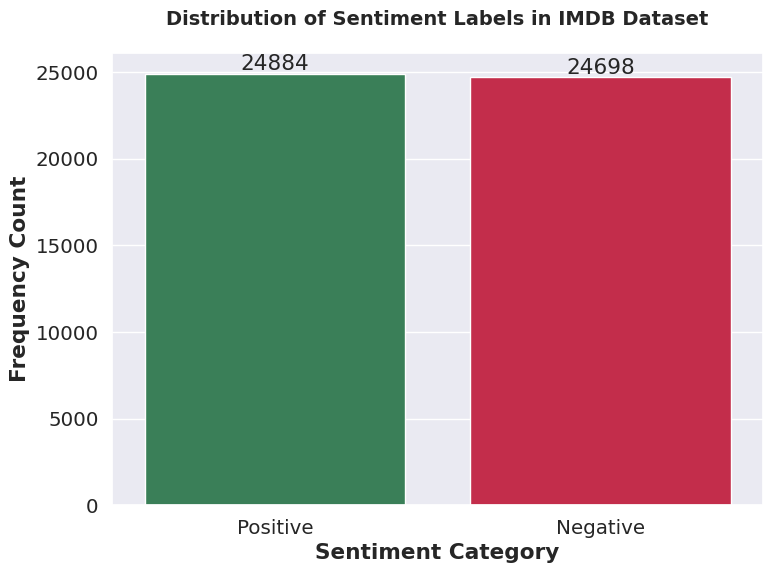

In [ ]:
# Configure plot aesthetics
plt.figure(figsize=(8, 6))
sns.set_theme(style="darkgrid", font_scale=1.3)

# Create count visualization with custom styling
sentiment_plot = sns.countplot(
    data=data,
    x='sentiment',
    palette=['#2E8B57', '#DC143C'],  # SeaGreen and Crimson colors
    order=[1, 0],
    dodge=False
)

# Customize axis labels and formatting
sentiment_plot.set_xticks([0, 1])
sentiment_plot.set_xticklabels(['Positive', 'Negative'])
sentiment_plot.set_xlabel('Sentiment Category', fontweight='bold')
sentiment_plot.set_ylabel('Frequency Count', fontweight='bold')

# Add title with custom formatting
plt.title('Distribution of Sentiment Labels in IMDB Dataset',
          fontsize=14, fontweight='bold', pad=20)

# Add value labels on top of bars
for container in sentiment_plot.containers:
    sentiment_plot.bar_label(container, fmt='%d')

# Improve layout and display
plt.tight_layout()
plt.show()

In [ ]:
# Calculate sentiment distribution statistics
sentiment_counts = data['sentiment'].value_counts()
total_samples = len(data)

# Extract counts for each sentiment category
positive_count = sentiment_counts[1]  # Assuming 1 represents positive
negative_count = sentiment_counts[0]  # Assuming 0 represents negative

# Calculate percentages
positive_percentage = (positive_count / total_samples) * 100
negative_percentage = (negative_count / total_samples) * 100

# Display results with formatted output
print(f"Dataset Composition Summary:")
print(f"─" * 40)
print(f"Positive sentiment: {positive_count:,} samples ({positive_percentage:.1f}% of total)")
print(f"Negative sentiment: {negative_count:,} samples ({negative_percentage:.1f}% of total)")
print(f"─" * 40)
print(f"Total dataset size: {total_samples:,} reviews")

Dataset Composition Summary:
────────────────────────────────────────
Positive sentiment: 24,884 samples (50.2% of total)
Negative sentiment: 24,698 samples (49.8% of total)
────────────────────────────────────────
Total dataset size: 49,582 reviews


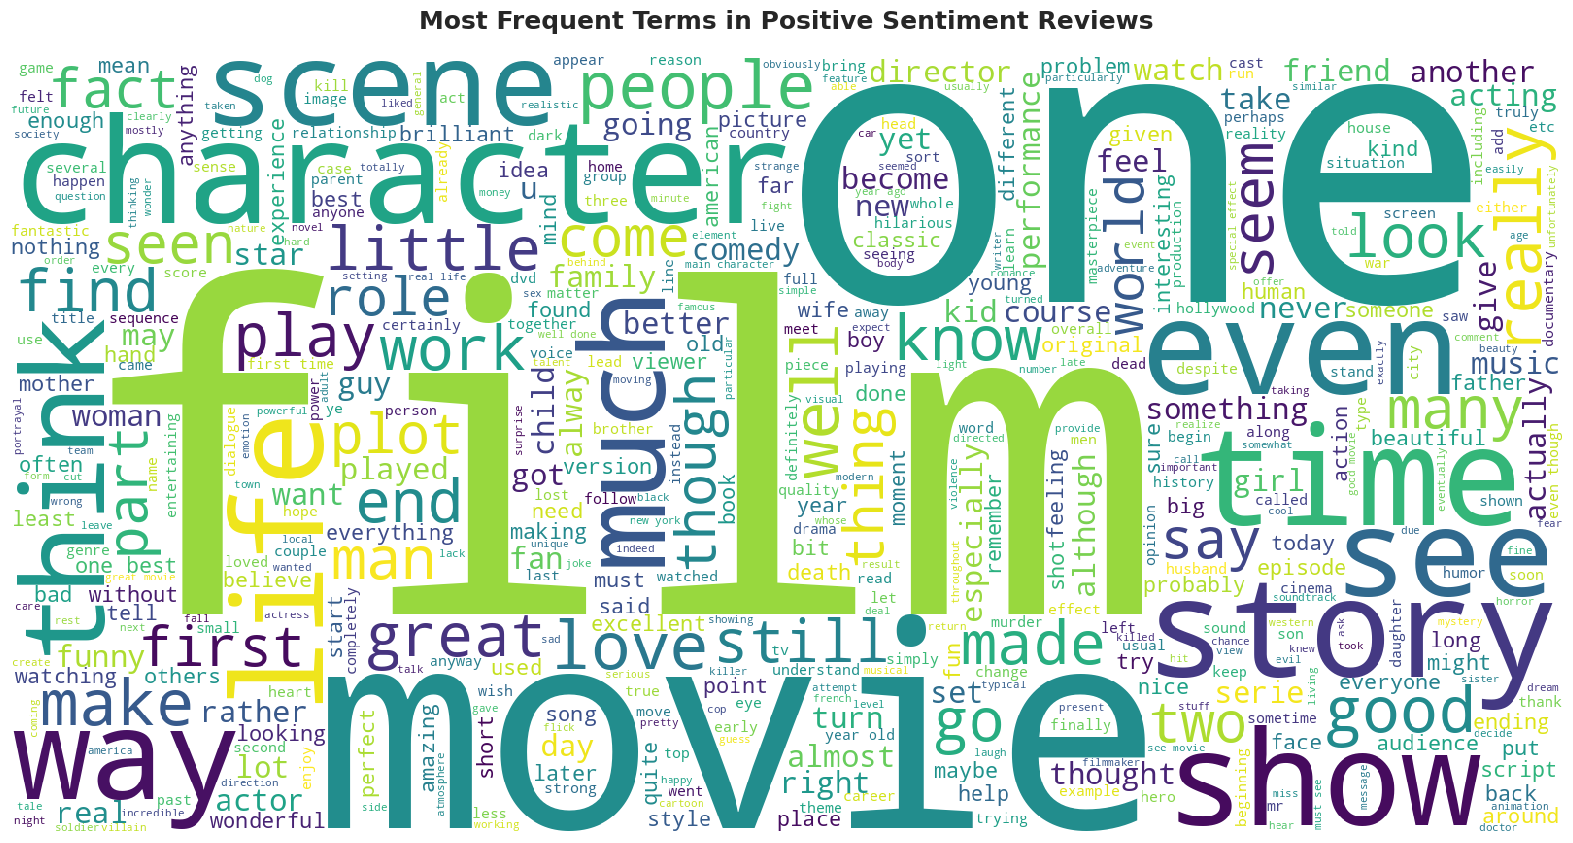

In [ ]:
# Filter and extract positive sentiment reviews
positive_reviews = data.loc[data['sentiment'] == 1, 'review']

# Combine all positive reviews into a single text corpus
combined_positive_text = ' '.join(positive_reviews.astype(str))

# Configure visualization parameters
fig, ax = plt.subplots(figsize=(16, 10))

# Create word cloud with custom parameters
wordcloud_generator = WordCloud(
    max_words=1500,
    width=1600,
    height=800,
    background_color='white',
    colormap='viridis',
    relative_scaling=0.5,
    min_font_size=10
).generate(combined_positive_text)

# Display the word cloud
ax.imshow(wordcloud_generator, interpolation='nearest')
ax.set_axis_off()
ax.set_title('Most Frequent Terms in Positive Sentiment Reviews',
             fontsize=18, fontweight='bold', pad=20)

# Enhance layout and show plot
plt.tight_layout()
plt.show()

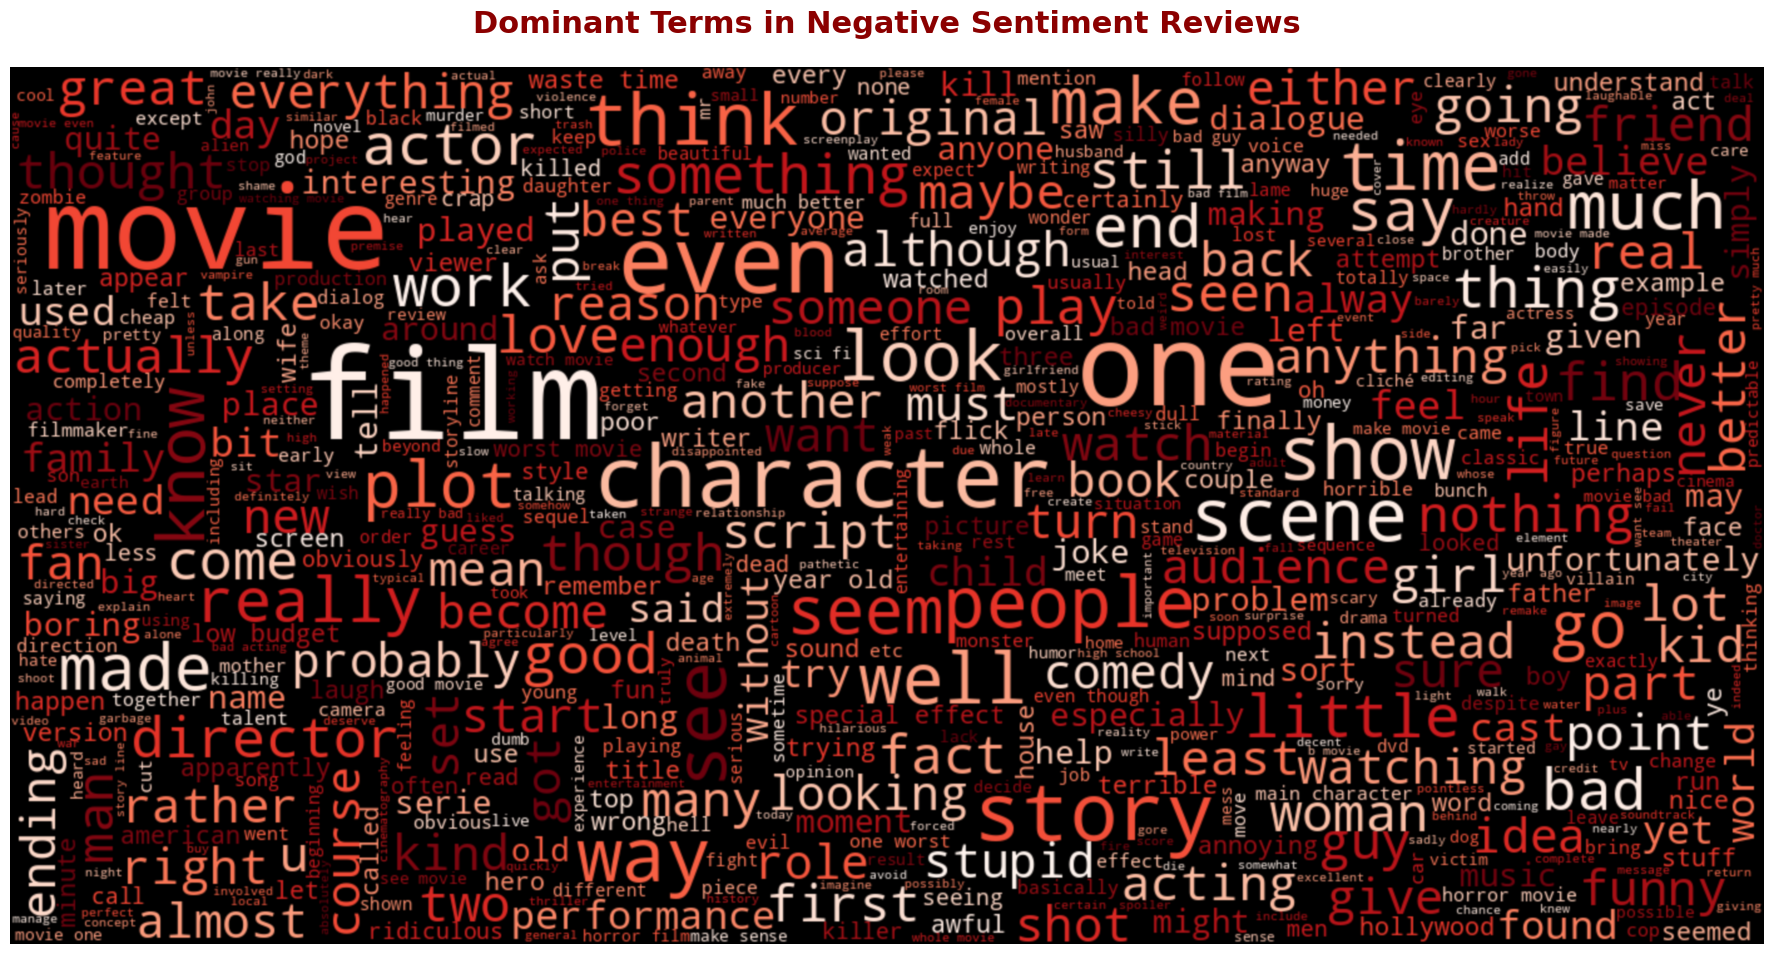

Generated word cloud from 24698 negative reviews
Total characters processed: 19,367,062


In [ ]:
# Extract negative sentiment reviews from dataset
negative_review_subset = data.query('sentiment == 0')['review']

# Concatenate all negative reviews into unified text
aggregated_negative_text = ' '.join(negative_review_subset.dropna().astype(str))

# Set up figure with custom dimensions
plt.figure(figsize=(18, 12))

# Generate word cloud with distinctive styling
negative_wordcloud = WordCloud(
    max_words=1800,
    width=1400,
    height=700,
    background_color='black',
    colormap='Reds',
    max_font_size=100,
    min_font_size=8,
    prefer_horizontal=0.9
).generate(aggregated_negative_text)

# Render the word cloud visualization
plt.imshow(negative_wordcloud, interpolation='bicubic')
plt.axis('off')
plt.title('Dominant Terms in Negative Sentiment Reviews',
          fontsize=22, color='darkred', fontweight='bold', pad=25)

# Apply styling and display
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Generated word cloud from {len(negative_review_subset)} negative reviews")
print(f"Total characters processed: {len(aggregated_negative_text):,}")

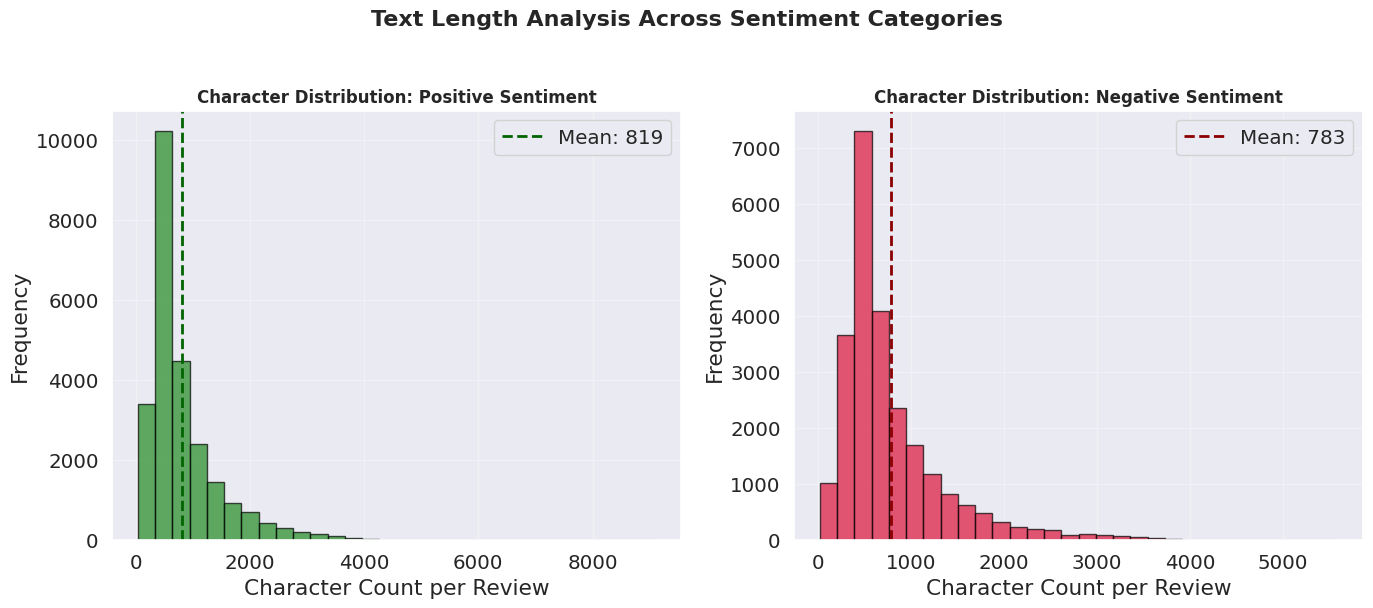

Review Length Statistics:
Positive reviews - Mean: 819.1, Median: 591.0
Negative reviews - Mean: 783.2, Median: 586.0


In [ ]:
# Create subplot configuration
figure, (left_plot, right_plot) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Extract review text for each sentiment category
positive_reviews = data[data['sentiment'] == 1]['review']
negative_reviews = data[data['sentiment'] == 0]['review']

# Calculate character lengths for positive reviews
positive_char_lengths = positive_reviews.str.len()
left_plot.hist(positive_char_lengths, bins=30, color='#228B22', alpha=0.7, edgecolor='black')
left_plot.set_title('Character Distribution: Positive Sentiment', fontweight='bold', fontsize=12)
left_plot.set_xlabel('Character Count per Review')
left_plot.set_ylabel('Frequency')
left_plot.grid(True, alpha=0.3)

# Calculate character lengths for negative reviews
negative_char_lengths = negative_reviews.str.len()
right_plot.hist(negative_char_lengths, bins=30, color='#DC143C', alpha=0.7, edgecolor='black')
right_plot.set_title('Character Distribution: Negative Sentiment', fontweight='bold', fontsize=12)
right_plot.set_xlabel('Character Count per Review')
right_plot.set_ylabel('Frequency')
right_plot.grid(True, alpha=0.3)

# Add overall title and formatting
figure.suptitle('Text Length Analysis Across Sentiment Categories',
                fontsize=16, fontweight='bold', y=1.02)

# Add statistical annotations
pos_mean = np.mean(positive_char_lengths)
neg_mean = np.mean(negative_char_lengths)

left_plot.axvline(pos_mean, color='darkgreen', linestyle='--', linewidth=2,
                  label=f'Mean: {pos_mean:.0f}')
right_plot.axvline(neg_mean, color='darkred', linestyle='--', linewidth=2,
                   label=f'Mean: {neg_mean:.0f}')

left_plot.legend()
right_plot.legend()

# Improve layout and display
plt.tight_layout()
plt.show()

# Print summary statistics
print("Review Length Statistics:")
print(f"Positive reviews - Mean: {pos_mean:.1f}, Median: {np.median(positive_char_lengths):.1f}")
print(f"Negative reviews - Mean: {neg_mean:.1f}, Median: {np.median(negative_char_lengths):.1f}")

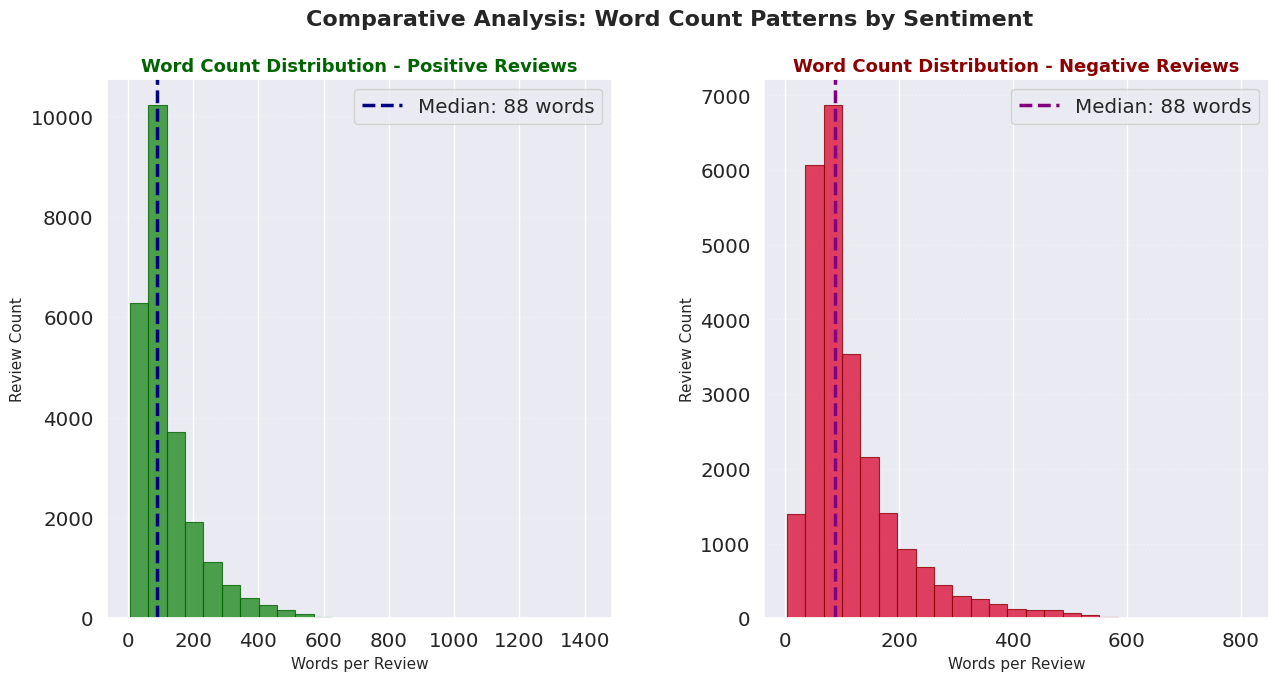

Word Count Analysis Summary:
--------------------------------------------------
Positive Reviews:
  • Average words: 119.9
  • Median words: 88
  • Max words: 1414

Negative Reviews:
  • Average words: 116.2
  • Median words: 88
  • Max words: 810


In [ ]:
# Configure subplot layout
fig_obj, (subplot_1, subplot_2) = plt.subplots(1, 2, figsize=(15, 7))

# Extract sentiment-specific review data
pos_sentiment_reviews = data[data['sentiment'] == 1]['review']
neg_sentiment_reviews = data[data['sentiment'] == 0]['review']

# Calculate word counts for positive reviews
positive_word_counts = pos_sentiment_reviews.str.split().apply(len)
subplot_1.hist(positive_word_counts, bins=25, color='forestgreen', alpha=0.8,
               density=False, edgecolor='darkgreen', linewidth=0.8)
subplot_1.set_title('Word Count Distribution - Positive Reviews',
                    fontsize=13, fontweight='bold', color='darkgreen')
subplot_1.set_xlabel('Words per Review', fontsize=11)
subplot_1.set_ylabel('Review Count', fontsize=11)
subplot_1.grid(axis='y', alpha=0.4, linestyle=':')

# Calculate word counts for negative reviews
negative_word_counts = neg_sentiment_reviews.str.split().apply(len)
subplot_2.hist(negative_word_counts, bins=25, color='crimson', alpha=0.8,
               density=False, edgecolor='darkred', linewidth=0.8)
subplot_2.set_title('Word Count Distribution - Negative Reviews',
                    fontsize=13, fontweight='bold', color='darkred')
subplot_2.set_xlabel('Words per Review', fontsize=11)
subplot_2.set_ylabel('Review Count', fontsize=11)
subplot_2.grid(axis='y', alpha=0.4, linestyle=':')

# Add comprehensive title
fig_obj.suptitle('Comparative Analysis: Word Count Patterns by Sentiment',
                 fontsize=16, fontweight='bold', y=0.98)

# Add statistical markers
pos_median = np.median(positive_word_counts)
neg_median = np.median(negative_word_counts)

subplot_1.axvline(pos_median, color='navy', linestyle='--', linewidth=2.5,
                  label=f'Median: {pos_median:.0f} words')
subplot_2.axvline(neg_median, color='purple', linestyle='--', linewidth=2.5,
                  label=f'Median: {neg_median:.0f} words')

# Display legends and format layout
subplot_1.legend(loc='upper right')
subplot_2.legend(loc='upper right')
plt.subplots_adjust(wspace=0.3)
plt.show()

# Output descriptive statistics
print("Word Count Analysis Summary:")
print("-" * 50)
print(f"Positive Reviews:")
print(f"  • Average words: {np.mean(positive_word_counts):.1f}")
print(f"  • Median words: {pos_median:.0f}")
print(f"  • Max words: {np.max(positive_word_counts)}")
print(f"\nNegative Reviews:")
print(f"  • Average words: {np.mean(negative_word_counts):.1f}")
print(f"  • Median words: {neg_median:.0f}")
print(f"  • Max words: {np.max(negative_word_counts)}")

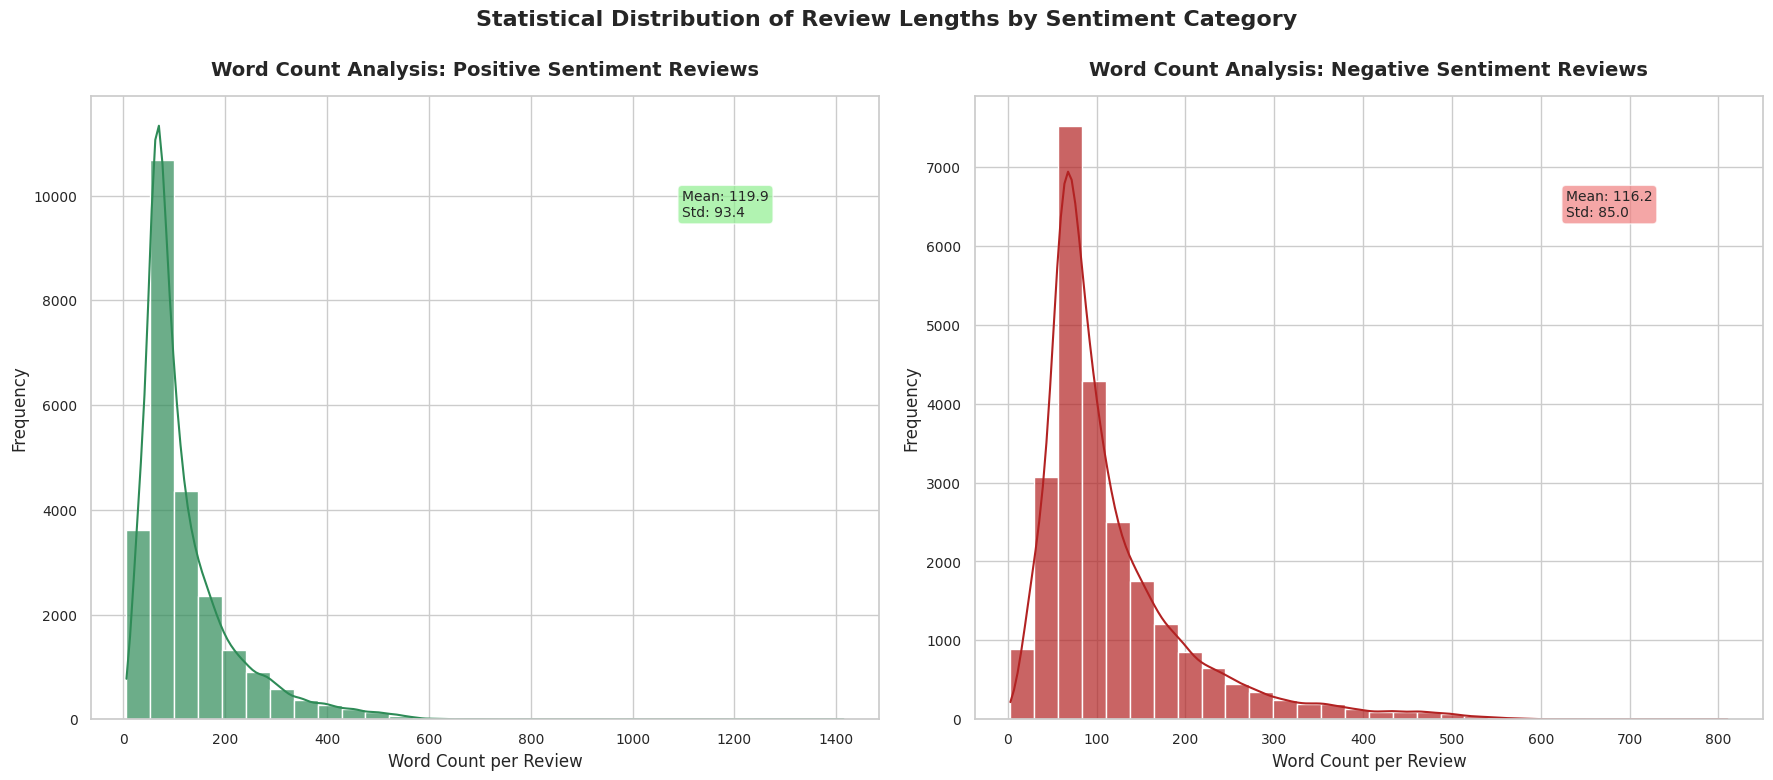

Review Length Comparison:
Positive Reviews - Average: 119.91 words
Negative Reviews - Average: 116.23 words
Difference: 3.67 words


In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Create figure with subplots
figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(18, 8))

# Extract review data by sentiment
positive_sentiment_data = data[data['sentiment'] == 1]['review']
negative_sentiment_data = data[data['sentiment'] == 0]['review']

# Calculate word counts for positive sentiment
pos_word_lengths = positive_sentiment_data.str.split().apply(lambda tokens: len(tokens))
sns.histplot(data=pos_word_lengths, ax=left_axis, color='#2E8B57',
             kde=True, alpha=0.7, bins=30, stat='count')
left_axis.set_title('Word Count Analysis: Positive Sentiment Reviews',
                    fontsize=14, fontweight='bold', pad=15)
left_axis.set_xlabel('Word Count per Review', fontsize=12)
left_axis.set_ylabel('Frequency', fontsize=12)

# Calculate word counts for negative sentiment
neg_word_lengths = negative_sentiment_data.str.split().apply(lambda tokens: len(tokens))
sns.histplot(data=neg_word_lengths, ax=right_axis, color='#B22222',
             kde=True, alpha=0.7, bins=30, stat='count')
right_axis.set_title('Word Count Analysis: Negative Sentiment Reviews',
                     fontsize=14, fontweight='bold', pad=15)
right_axis.set_xlabel('Word Count per Review', fontsize=12)
right_axis.set_ylabel('Frequency', fontsize=12)

# Add overall figure title
figure.suptitle('Statistical Distribution of Review Lengths by Sentiment Category',
                fontsize=16, fontweight='bold', y=0.98)

# Customize appearance
left_axis.tick_params(labelsize=10)
right_axis.tick_params(labelsize=10)

# Add statistical annotations
pos_stats = f"Mean: {np.mean(pos_word_lengths):.1f}\nStd: {np.std(pos_word_lengths):.1f}"
neg_stats = f"Mean: {np.mean(neg_word_lengths):.1f}\nStd: {np.std(neg_word_lengths):.1f}"

left_axis.text(0.75, 0.85, pos_stats, transform=left_axis.transAxes,
               bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7),
               fontsize=10, verticalalignment='top')
right_axis.text(0.75, 0.85, neg_stats, transform=right_axis.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7),
                fontsize=10, verticalalignment='top')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print comparison summary
print("Review Length Comparison:")
print(f"Positive Reviews - Average: {np.mean(pos_word_lengths):.2f} words")
print(f"Negative Reviews - Average: {np.mean(neg_word_lengths):.2f} words")
print(f"Difference: {abs(np.mean(pos_word_lengths) - np.mean(neg_word_lengths)):.2f} words")

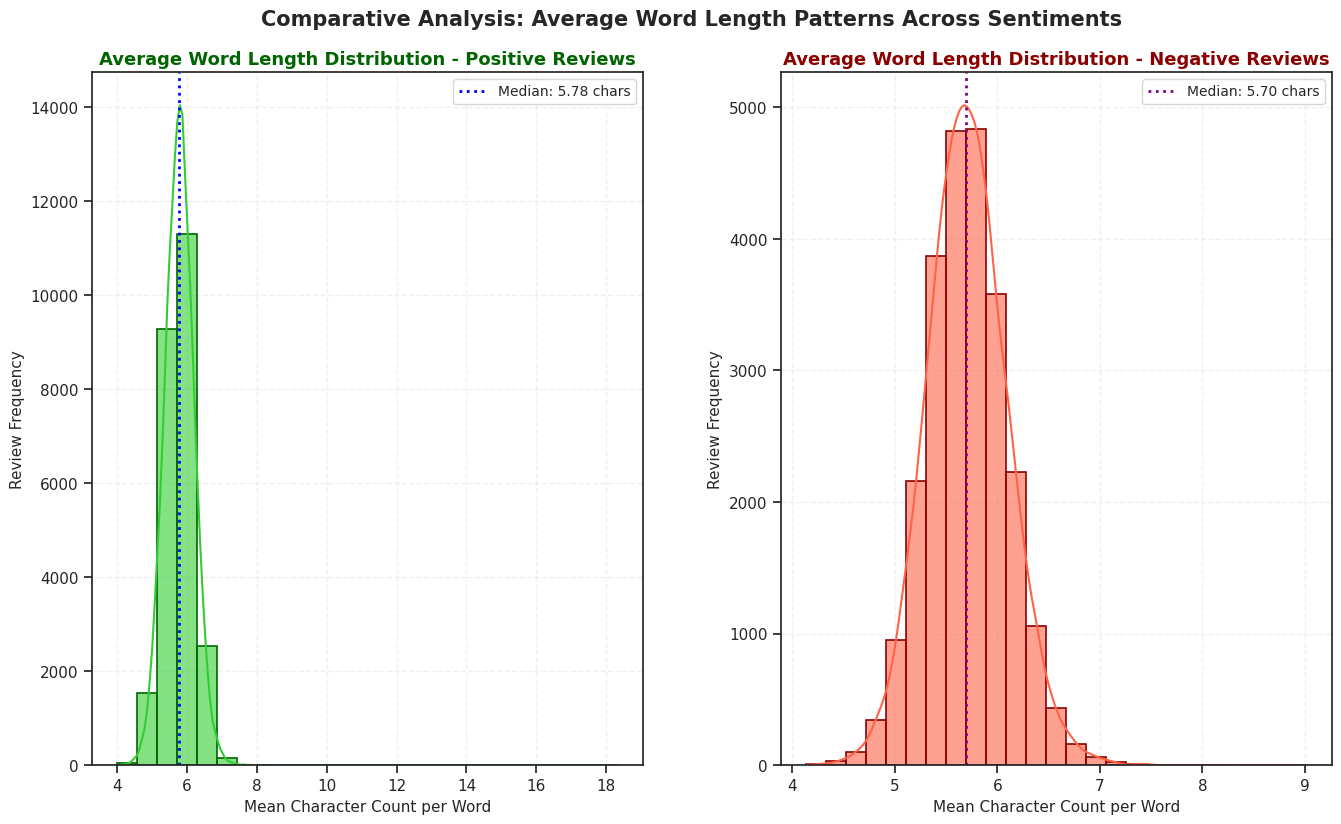

Average Word Length Analysis Report:
Positive Reviews:
  • Mean avg word length: 5.784 characters
  • Median avg word length: 5.784 characters
  • Standard deviation: 0.427

Negative Reviews:
  • Mean avg word length: 5.707 characters
  • Median avg word length: 5.699 characters
  • Standard deviation: 0.393

Difference in means: 0.077 characters


In [ ]:
# Configure seaborn aesthetics
sns.set_theme(style="ticks", palette="Set2")

# Create subplot configuration
plot_figure, (plot_left, plot_right) = plt.subplots(1, 2, figsize=(16, 9))

# Extract sentiment-based review data
reviews_positive = data[data['sentiment'] == 1]['review']
reviews_negative = data[data['sentiment'] == 0]['review']

# Calculate average character length per word for positive reviews
def calculate_avg_word_length(text_series):
    """Calculate average word length for each review in the series"""
    return text_series.str.split().apply(
        lambda word_list: np.mean([len(word) for word in word_list]) if word_list else 0
    )

positive_avg_lengths = calculate_avg_word_length(reviews_positive)
sns.histplot(data=positive_avg_lengths, ax=plot_left, color='#32CD32',
             kde=True, alpha=0.6, bins=25, edgecolor='darkgreen', linewidth=1.2)
plot_left.set_title('Average Word Length Distribution - Positive Reviews',
                    fontsize=13, fontweight='bold', color='darkgreen')
plot_left.set_xlabel('Mean Character Count per Word', fontsize=11)
plot_left.set_ylabel('Review Frequency', fontsize=11)
plot_left.grid(True, alpha=0.3, linestyle='--')

# Calculate average character length per word for negative reviews
negative_avg_lengths = calculate_avg_word_length(reviews_negative)
sns.histplot(data=negative_avg_lengths, ax=plot_right, color='#FF6347',
             kde=True, alpha=0.6, bins=25, edgecolor='darkred', linewidth=1.2)
plot_right.set_title('Average Word Length Distribution - Negative Reviews',
                     fontsize=13, fontweight='bold', color='darkred')
plot_right.set_xlabel('Mean Character Count per Word', fontsize=11)
plot_right.set_ylabel('Review Frequency', fontsize=11)
plot_right.grid(True, alpha=0.3, linestyle='--')

# Add comprehensive figure title
plot_figure.suptitle('Comparative Analysis: Average Word Length Patterns Across Sentiments',
                     fontsize=15, fontweight='bold', y=0.95)

# Add statistical reference lines
pos_median = np.median(positive_avg_lengths)
neg_median = np.median(negative_avg_lengths)

plot_left.axvline(pos_median, color='blue', linestyle=':', linewidth=2,
                  label=f'Median: {pos_median:.2f} chars')
plot_right.axvline(neg_median, color='purple', linestyle=':', linewidth=2,
                   label=f'Median: {neg_median:.2f} chars')

# Display legends and adjust layout
plot_left.legend(loc='upper right', fontsize=10)
plot_right.legend(loc='upper right', fontsize=10)
plt.subplots_adjust(wspace=0.25, top=0.88)
plt.show()

# Generate detailed statistics report
print("Average Word Length Analysis Report:")
print("=" * 45)
print(f"Positive Reviews:")
print(f"  • Mean avg word length: {np.mean(positive_avg_lengths):.3f} characters")
print(f"  • Median avg word length: {pos_median:.3f} characters")
print(f"  • Standard deviation: {np.std(positive_avg_lengths):.3f}")
print(f"\nNegative Reviews:")
print(f"  • Mean avg word length: {np.mean(negative_avg_lengths):.3f} characters")
print(f"  • Median avg word length: {neg_median:.3f} characters")
print(f"  • Standard deviation: {np.std(negative_avg_lengths):.3f}")
print(f"\nDifference in means: {abs(np.mean(positive_avg_lengths) - np.mean(negative_avg_lengths)):.3f} characters")

In [ ]:
def extract_word_tokens(text_data):
    """
    Extract individual words from a collection of text documents.

    Args:
        text_data: Series or list containing text documents

    Returns:
        list: Flattened list of individual word tokens
    """
    token_collection = []

    for document in text_data:
        if document is not None:  # Handle potential null values
            word_tokens = document.split()
            for token in word_tokens:
                clean_token = token.strip()
                if clean_token:  # Only add non-empty tokens
                    token_collection.append(clean_token)

    return token_collection

# Alternative implementation using list comprehension
def create_word_corpus(review_series):
    """
    Generate a corpus of words using list comprehension approach.

    Args:
        review_series: Pandas Series containing review text

    Returns:
        list: Complete word corpus from all reviews
    """
    word_corpus = [
        word.strip()
        for review in review_series.dropna()
        for word in review.split()
        if word.strip()
    ]
    return word_corpus

# Generate corpus using the primary function
review_corpus = extract_word_tokens(data['review'])

# Display first few tokens and basic statistics
print("Sample tokens from corpus:")
print(review_corpus[:5])
print(f"\nCorpus Statistics:")
print(f"Total words in corpus: {len(review_corpus):,}")
print(f"Unique words: {len(set(review_corpus)):,}")
print(f"Vocabulary diversity ratio: {len(set(review_corpus))/len(review_corpus):.4f}")

# Alternative corpus for comparison
alternative_corpus = create_word_corpus(data['review'])
print(f"\nVerification - Alternative method corpus size: {len(alternative_corpus):,}")

Sample tokens from corpus:
['one', 'reviewer', 'mentioned', 'watching', 'oz']

Corpus Statistics:
Total words in corpus: 5,854,465
Unique words: 92,096
Vocabulary diversity ratio: 0.0157

Verification - Alternative method corpus size: 5,854,465


In [ ]:
# Generate word frequency statistics
word_frequency_counter = Counter(review_corpus)

# Extract top 10 most frequent words
top_frequent_words = word_frequency_counter.most_common(10)

# Create DataFrame with descriptive column names
frequency_dataframe = pd.DataFrame(
    top_frequent_words,
    columns=['word_token', 'frequency_count']
)

# Add additional statistical columns
frequency_dataframe['percentage'] = (
    frequency_dataframe['frequency_count'] / len(review_corpus) * 100
).round(3)

frequency_dataframe['rank'] = range(1, len(frequency_dataframe) + 1)

# Reorder columns for better presentation
frequency_dataframe = frequency_dataframe[['rank', 'word_token', 'frequency_count', 'percentage']]

print("Top 10 Most Frequent Words in Corpus:")
print("=" * 50)
print(frequency_dataframe.to_string(index=False))

# Additional analysis
total_unique_words = len(word_frequency_counter)
top_10_coverage = frequency_dataframe['frequency_count'].sum()
coverage_percentage = (top_10_coverage / len(review_corpus)) * 100

print(f"\nFrequency Analysis Summary:")
print(f"• Total unique words in corpus: {total_unique_words:,}")
print(f"• Coverage by top 10 words: {coverage_percentage:.2f}%")
print(f"• Average frequency of top 10: {frequency_dataframe['frequency_count'].mean():.1f}")

# Display the DataFrame
frequency_dataframe

Top 10 Most Frequent Words in Corpus:
 rank word_token  frequency_count  percentage
    1      movie           102447       1.750
    2       film            92765       1.585
    3        one            55008       0.940
    4       like            40771       0.696
    5       time            31186       0.533
    6       good            29646       0.506
    7  character            28104       0.480
    8      story            25096       0.429
    9       even            24648       0.421
   10        get            24454       0.418

Frequency Analysis Summary:
• Total unique words in corpus: 92,096
• Coverage by top 10 words: 7.76%
• Average frequency of top 10: 45412.5


,rank,word_token,frequency_count,percentage
0,1,movie,102447,1.750
1,2,film,92765,1.585
2,3,one,55008,0.940
3,4,like,40771,0.696
4,5,time,31186,0.533
5,6,good,29646,0.506
6,7,character,28104,0.480
7,8,story,25096,0.429
8,9,even,24648,0.421
9,10,get,24454,0.418


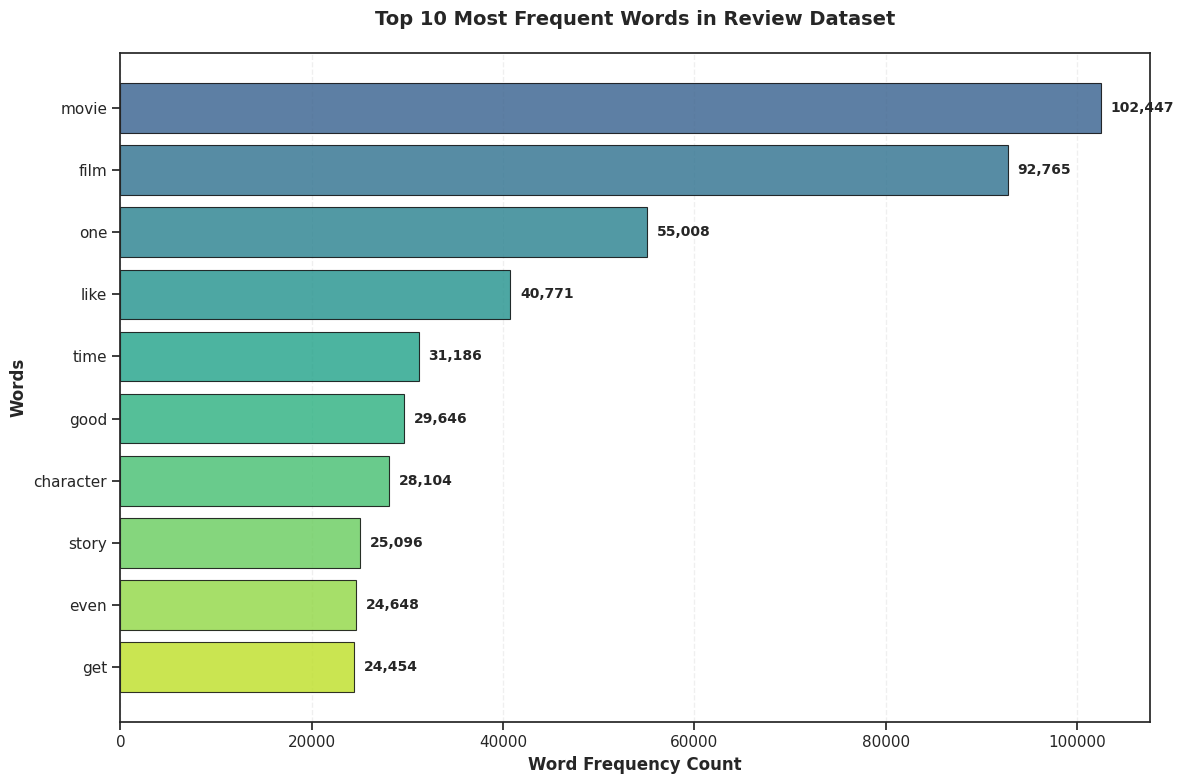

Visualization shows word frequencies ranging from 24,454 to 102,447
Most frequent word 'get' appears 24,454 times


In [ ]:
# Sort DataFrame by frequency for ascending order visualization
sorted_frequency_df = frequency_dataframe.sort_values('frequency_count', ascending=False)

# Create figure with custom styling
plt.figure(figsize=(12, 8))

# Generate color gradient for bars
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(sorted_frequency_df)))

# Create horizontal bar chart
bars = plt.barh(
    range(len(sorted_frequency_df)),
    sorted_frequency_df['frequency_count'],
    align='center',
    color=colors,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.8
)

# Configure y-axis with word labels
plt.yticks(range(len(sorted_frequency_df)), sorted_frequency_df['word_token'], fontsize=11)
plt.xlabel('Word Frequency Count', fontsize=12, fontweight='bold')
plt.ylabel('Words', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Frequent Words in Review Dataset',
          fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, sorted_frequency_df['frequency_count'])):
    plt.text(count + max(sorted_frequency_df['frequency_count']) * 0.01,
             i, f'{count:,}',
             va='center', ha='left', fontsize=10, fontweight='bold')

# Add grid for better readability
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Customize layout
plt.tight_layout()
plt.gca().invert_yaxis()  # Ensure highest frequency appears at top
plt.tight_layout()
plt.show()

# Print additional insights
print(f"Visualization shows word frequencies ranging from {sorted_frequency_df['frequency_count'].min():,} to {sorted_frequency_df['frequency_count'].max():,}")
print(f"Most frequent word '{sorted_frequency_df.iloc[-1]['word_token']}' appears {sorted_frequency_df.iloc[-1]['frequency_count']:,} times")

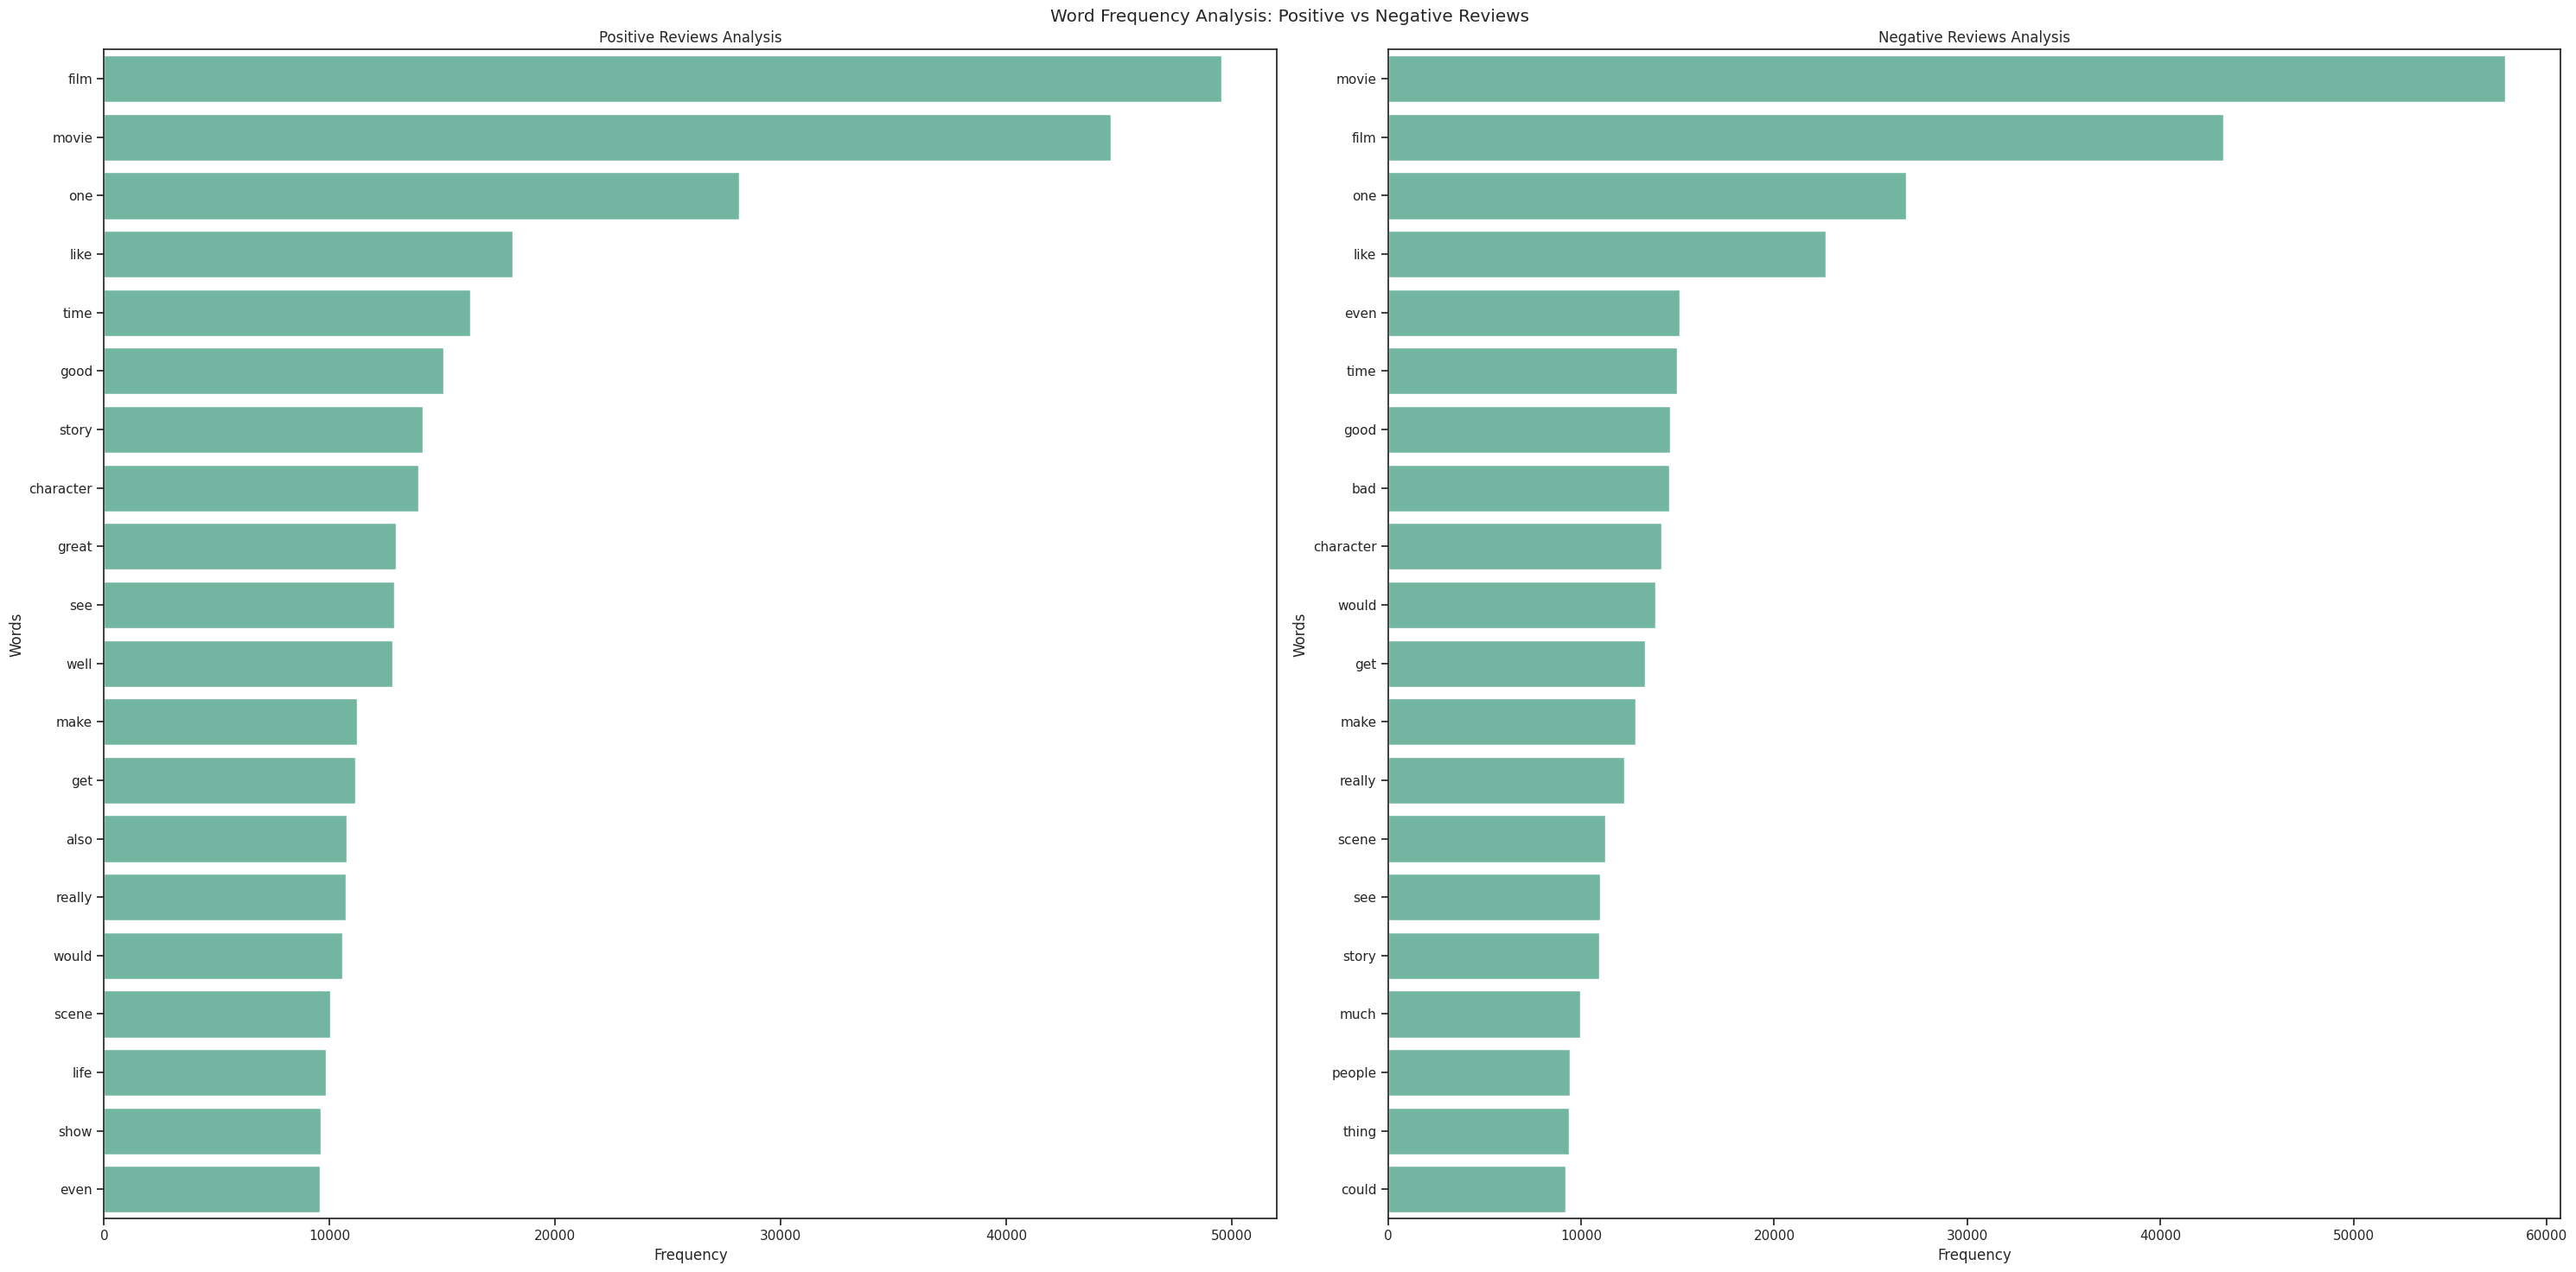

In [ ]:
def extract_ngrams(text_data, top_n, gram_size):
    vectorizer = CountVectorizer(ngram_range=(gram_size, gram_size)).fit(text_data)
    count_matrix = vectorizer.transform(text_data)  # sparse matrix from count_vectorizer
    word_counts = count_matrix.sum(axis=0)  # sum of word occurrences
    word_counts = np.array(word_counts)[0].tolist()  # convert to list format
    word_frequencies = [(term, word_counts[index]) for term, index in vectorizer.vocabulary_.items()]  # create word-frequency pairs
    word_frequencies = sorted(word_frequencies, key=lambda item: item[1], reverse=True)  # sort by frequency descending
    return word_frequencies[:top_n]

# Create subplot visualization
figure, (subplot1, subplot2) = plt.subplots(1, 2, figsize=(30, 15))

# Analyze positive reviews
positive_unigrams = extract_ngrams(positive_reviews, 20, 1)
positive_dict = dict(positive_unigrams)
df_positive = pd.DataFrame(list(positive_dict.items()), columns=["Words", "Frequency"])
sns.barplot(data=df_positive, x="Frequency", y="Words", orient='h', ax=subplot1)
subplot1.set_title('Positive Reviews Analysis')

# Analyze negative reviews
negative_unigrams = extract_ngrams(negative_reviews, 20, 1)
negative_dict = dict(negative_unigrams)
df_negative = pd.DataFrame(list(negative_dict.items()), columns=["Words", "Frequency"])
sns.barplot(data=df_negative, x="Frequency", y="Words", orient='h', ax=subplot2)
subplot2.set_title('Negative Reviews Analysis')

figure.suptitle('Word Frequency Analysis: Positive vs Negative Reviews')
plt.tight_layout()
plt.show()

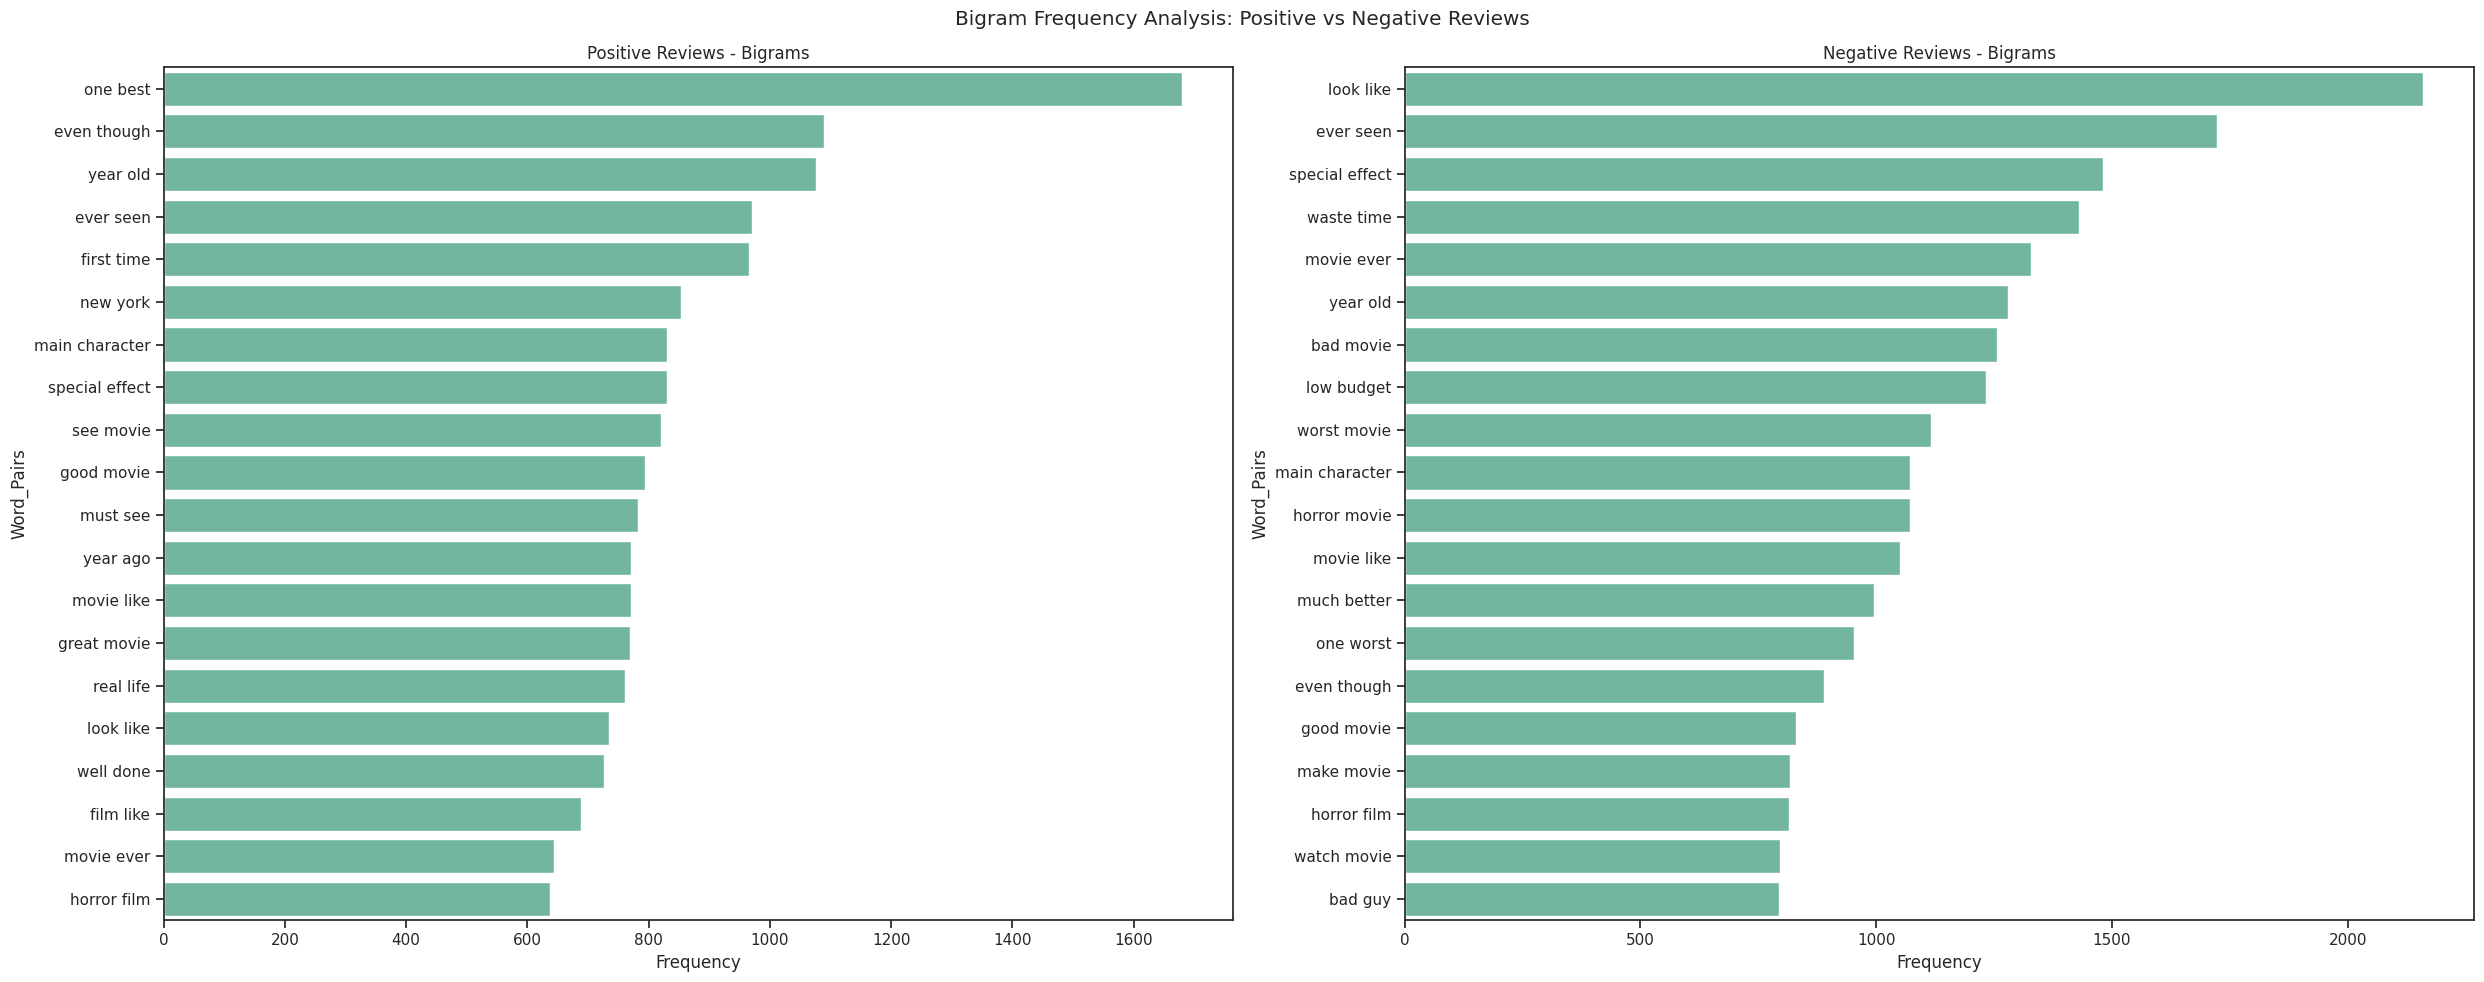

In [ ]:
# Create visualization for bigram analysis
figure, (subplot1, subplot2) = plt.subplots(1, 2, figsize=(25, 10))

# Extract positive bigrams
positive_bigrams = extract_ngrams(positive_reviews, 20, 2)
positive_dict = dict(positive_bigrams)
df_pos = pd.DataFrame(list(positive_dict.items()), columns=["Word_Pairs", "Frequency"])
sns.barplot(data=df_pos, x="Frequency", y="Word_Pairs", orient='h', ax=subplot1)
subplot1.set_title('Positive Reviews - Bigrams')

# Extract negative bigrams
negative_bigrams = extract_ngrams(negative_reviews, 20, 2)
negative_dict = dict(negative_bigrams)
df_neg = pd.DataFrame(list(negative_dict.items()), columns=["Word_Pairs", "Frequency"])
sns.barplot(data=df_neg, x="Frequency", y="Word_Pairs", orient='h', ax=subplot2)
subplot2.set_title('Negative Reviews - Bigrams')

figure.suptitle('Bigram Frequency Analysis: Positive vs Negative Reviews')
plt.tight_layout()
plt.show()

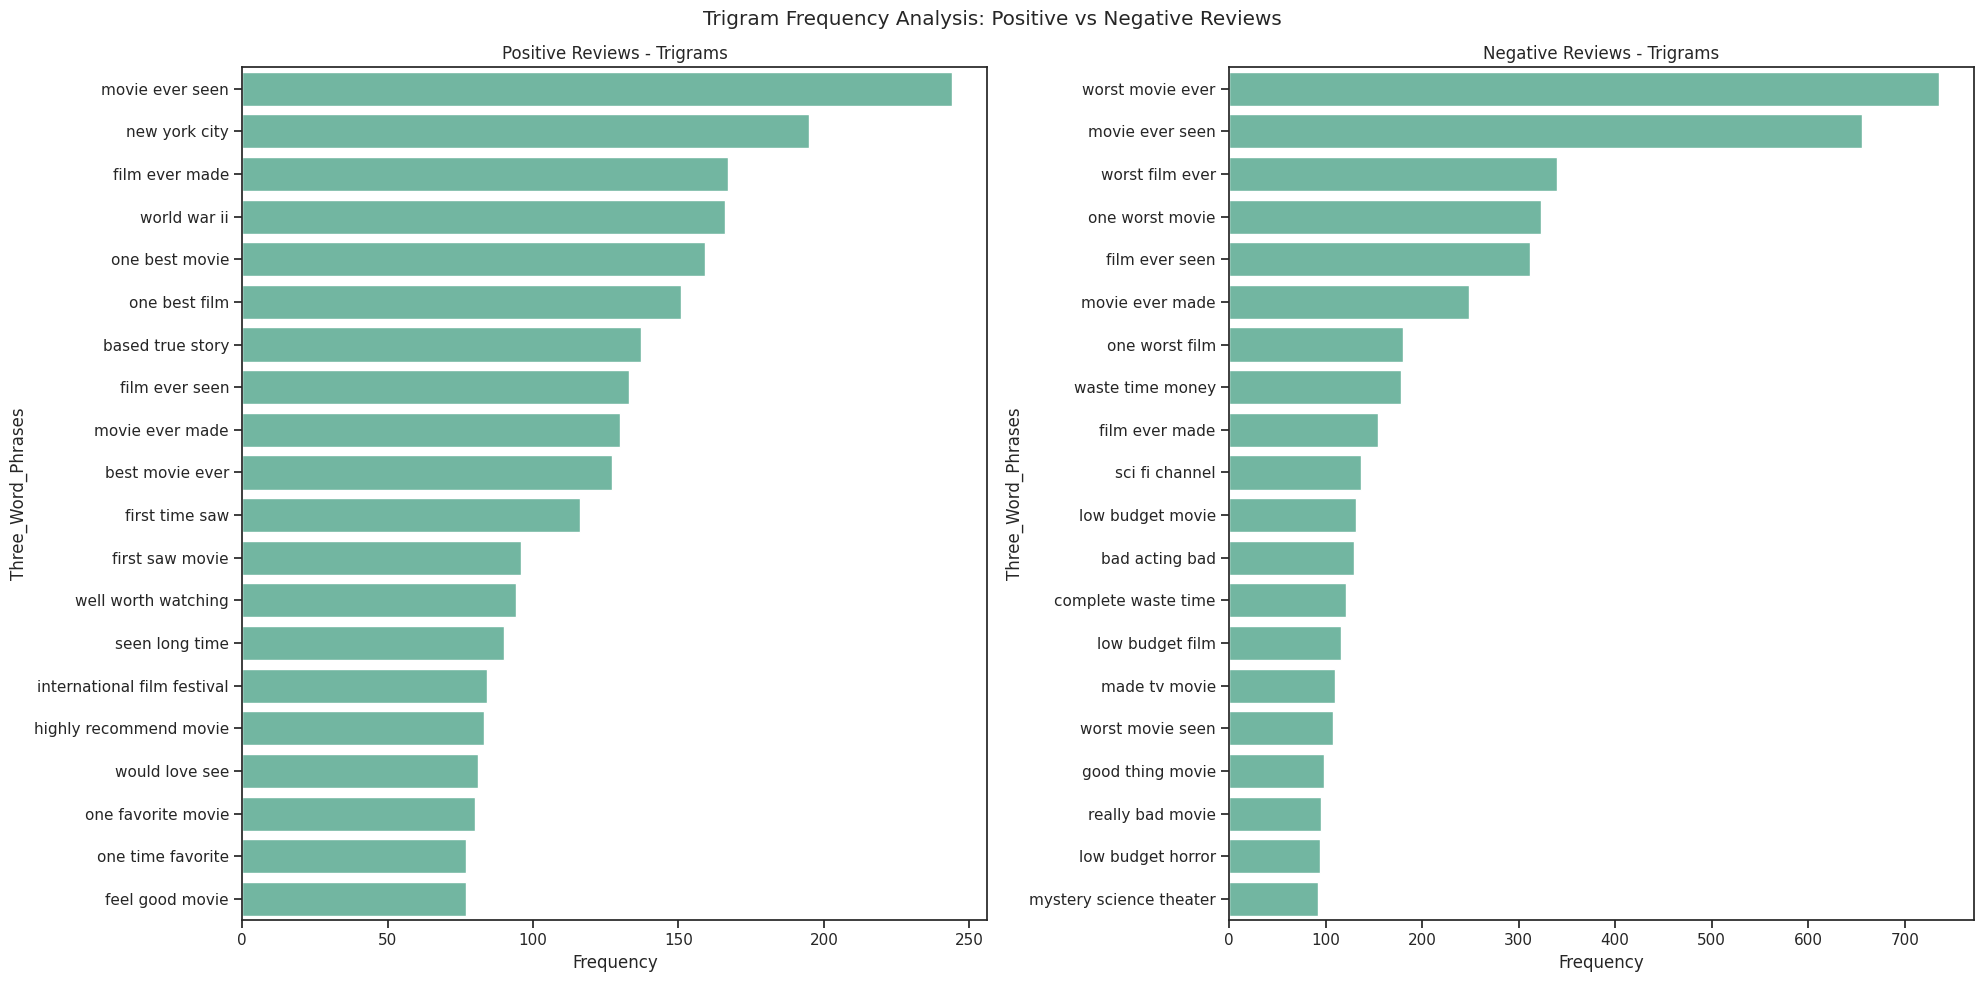

In [ ]:
# Create visualization for trigram analysis
figure, (subplot1, subplot2) = plt.subplots(1, 2, figsize=(20, 10))

# Extract positive trigrams
positive_trigrams = extract_ngrams(positive_reviews, 20, 3)
pos_trigram_dict = dict(positive_trigrams)
df_pos_tri = pd.DataFrame(list(pos_trigram_dict.items()), columns=["Three_Word_Phrases", "Frequency"])
sns.barplot(data=df_pos_tri, x="Frequency", y="Three_Word_Phrases", orient='h', ax=subplot1)
subplot1.set_title('Positive Reviews - Trigrams')

# Extract negative trigrams
negative_trigrams = extract_ngrams(negative_reviews, 20, 3)
neg_trigram_dict = dict(negative_trigrams)
df_neg_tri = pd.DataFrame(list(neg_trigram_dict.items()), columns=["Three_Word_Phrases", "Frequency"])
sns.barplot(data=df_neg_tri, x="Frequency", y="Three_Word_Phrases", orient='h', ax=subplot2)
subplot2.set_title('Negative Reviews - Trigrams')

figure.suptitle('Trigram Frequency Analysis: Positive vs Negative Reviews')
plt.tight_layout()
plt.show()

# d. Machine Learning Models

In [ ]:
# Data splitting for model training and evaluation
training_set, testing_set = train_test_split(data, test_size=0.2, random_state=42)
X_train, y_train = training_set['review'], training_set['sentiment']
X_test, y_test = testing_set['review'], testing_set['sentiment']

In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()  # Initialize TF-IDF vectorizer
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Count Vectorization
count_vectorizer = CountVectorizer()  # Initialize Count vectorizer
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

### Logistic Regression

Logistic Regression Accuracy: 89.32%


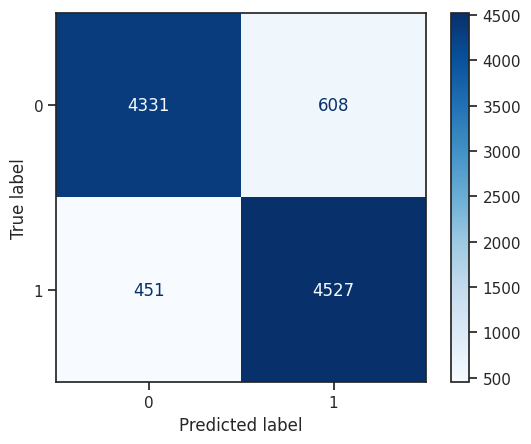

In [ ]:
# Logistic Regression Model Training and Evaluation
logistic_model = LogisticRegression()
logistic_model.fit(X_train_tfidf, y_train)
predictions = logistic_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predictions)
print("Logistic Regression Accuracy: {:.2f}%".format(100 * accuracy))
ConfusionMatrixDisplay.from_estimator(logistic_model, X_test_tfidf, y_test, cmap='Blues')
plt.grid(False)

### Multinomial Naive Bayes

Multinomial Naive Bayes Accuracy: 86.65%


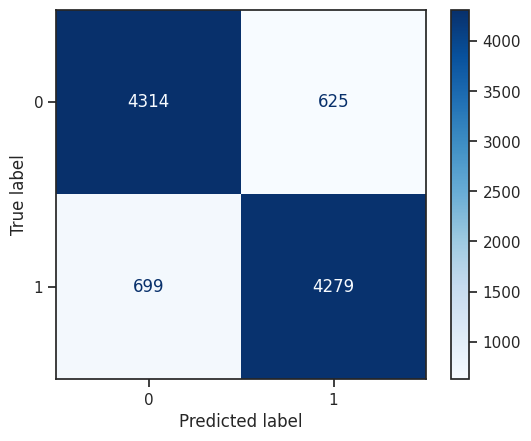

In [ ]:
# Multinomial Naive Bayes Model Training and Evaluation
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_tfidf, y_train)
nb_predictions = naive_bayes_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Multinomial Naive Bayes Accuracy: {:.2f}%".format(100 * nb_accuracy))
ConfusionMatrixDisplay.from_estimator(naive_bayes_model, X_test_tfidf, y_test, cmap='Blues')
plt.grid(False)

### Linear SVM

Linear SVM Classifier Accuracy: 89.95%


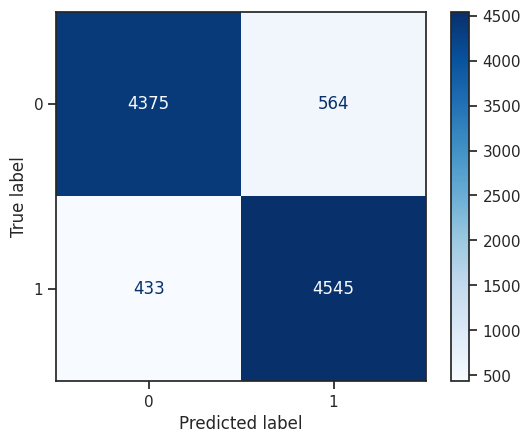

In [ ]:
# Linear Support Vector Classifier Training and Evaluation
svm_model = LinearSVC(penalty='l2', loss='hinge')
svm_model.fit(X_train_tfidf, y_train)
svm_predictions = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("Linear SVM Classifier Accuracy: {:.2f}%".format(100 * svm_accuracy))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_tfidf, y_test, cmap='Blues')
plt.grid(False)

### XGBoost

XGBoost Classifier Accuracy: 85.01%


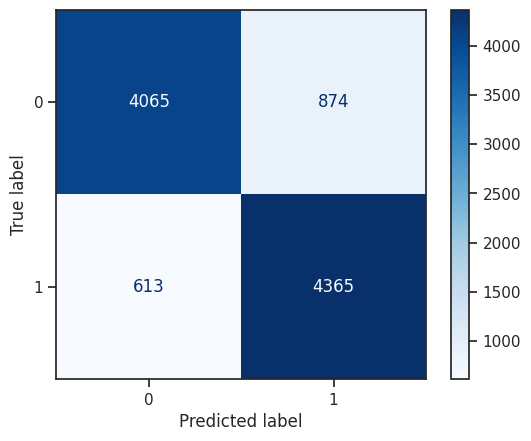

In [ ]:
# XGBoost Classifier Training and Evaluation
xgb_model = XGBClassifier()
xgb_model.fit(X_train_tfidf, y_train)
xgb_predictions = xgb_model.predict(X_test_tfidf)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print("XGBoost Classifier Accuracy: {:.2f}%".format(100 * xgb_accuracy))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test_tfidf, y_test, cmap='Blues')
plt.grid(False)

# e. Deep Learning Models

In [ ]:
# Function to visualize training progress
def display_training_curves(training_history, num_epochs):
    epoch_values = range(1, num_epochs + 1)
    figure, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].plot(epoch_values, training_history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(epoch_values, training_history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy Progress')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epoch_values, training_history.history['loss'], label='Training Loss')
    axes[1].plot(epoch_values, training_history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss Progress')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    figure.tight_layout()
    plt.show()

In [ ]:
# Prepare data for deep learning model
dataset_copy = data_copy.copy()
dataset_copy['review'] = dataset_copy['review'].apply(preprocess_text, apply_lemmatization=False)
# Convert sentiment labels to binary values
dataset_copy.sentiment = [1 if label == "positive" else 0 for label in dataset_copy.sentiment]

# Split dataset for training and testing
train_data, test_data = train_test_split(dataset_copy, test_size=0.2, random_state=42)
X_train_text, y_train_labels = train_data['review'], train_data['sentiment']
X_test_text, y_test_labels = test_data['review'], test_data['sentiment']

### LSTM

Dataset vocabulary size: 92435
Absolute maximum sequence length: 1414
Optimal sequence length (mean + 2*std): 296
This length covers approximately 94.51% of the data
----Constructing the model----


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 296)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 296, 64)        │     5,915,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 296, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 296, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 292, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 292, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 146, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 146, 256)       │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,173,537 (23.55 MB)

 Trainable params: 6,173,409 (23.55 MB)

 Non-trainable params: 128 (512.00 B)

----Training the model----
Epoch 1/5
992/992 - 34s - 34ms/step - accuracy: 0.6737 - loss: 0.5706 - val_accuracy: 0.8663 - val_loss: 0.3243
Epoch 2/5
992/992 - 36s - 36ms/step - accuracy: 0.8764 - loss: 0.2999 - val_accuracy: 0.8548 - val_loss: 0.3251
Epoch 3/5
992/992 - 41s - 41ms/step - accuracy: 0.9111 - loss: 0.2266 - val_accuracy: 0.8955 - val_loss: 0.2566
Epoch 4/5
992/992 - 41s - 41ms/step - accuracy: 0.9298 - loss: 0.1891 - val_accuracy: 0.8950 - val_loss: 0.2616
Epoch 5/5
992/992 - 25s - 25ms/step - accuracy: 0.9466 - loss: 0.1474 - val_accuracy: 0.8883 - val_loss: 0.2887
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9791 - loss: 0.0748
Training score: [0.07320687919855118, 0.9809025526046753]
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8953 - loss: 0.2757
Validation score: [0.28868210315704346, 0.8883146643638611]


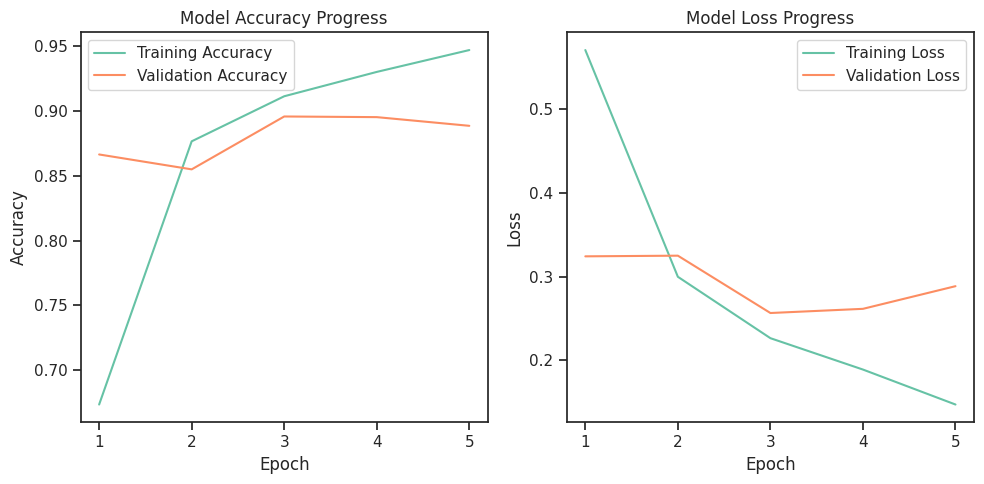

Evaluating Model Performance on Test Dataset
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8862 - loss: 0.3073
{'loss': 0.30581900477409363, 'compile_metrics': 0.8879701495170593}
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


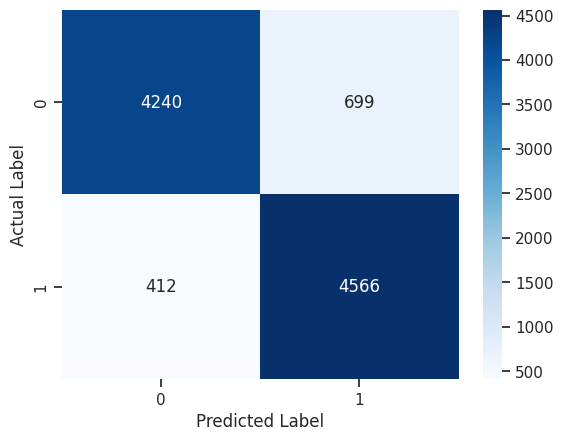

In [ ]:
# Initialize tokenizer for text processing
VOCABULARY_SIZE = 10000
text_tokenizer = Tokenizer(num_words=VOCABULARY_SIZE, oov_token="<oov>")
text_tokenizer.fit_on_texts(X_train_text)
vocabulary_dict = text_tokenizer.word_index
vocab_size = len(vocabulary_dict)
print("Dataset vocabulary size:", vocab_size)

# Convert text to numerical sequences
train_sequences = text_tokenizer.texts_to_sequences(X_train_text)
test_sequences = text_tokenizer.texts_to_sequences(X_test_text)

# Determine optimal sequence length
sequence_lengths = [len(seq) for seq in train_sequences + test_sequences]

# Calculate maximum sequence length
absolute_max = max(sequence_lengths)
print('Absolute maximum sequence length: {}'.format(absolute_max))

# Use statistical approach for sequence length
optimal_length = np.mean(sequence_lengths) + 2 * np.std(sequence_lengths)
optimal_length = int(optimal_length)
print('Optimal sequence length (mean + 2*std): {}'.format(optimal_length))

coverage_percentage = np.sum(np.array(sequence_lengths) < optimal_length) / len(sequence_lengths) * 100
print('This length covers approximately {:.2f}% of the data'.format(coverage_percentage))

# Create padded sequences for consistent input size
padded_train = pad_sequences(train_sequences, truncating='post', padding='pre', maxlen=optimal_length)
padded_test = pad_sequences(test_sequences, truncating='post', padding='pre', maxlen=optimal_length)

# Create validation split from training data
X_train_final, X_validation, y_train_final, y_validation = train_test_split(
    padded_train, y_train_labels, test_size=0.2, random_state=10)

def create_lstm_model(X_train_data, X_val_data, y_train_data, y_val_data, vocab_size, embedding_dim, seq_length, training_epochs):

    print("----Constructing the model----")
    input_layer = Input(shape=(seq_length,))
    embedding_layer = Embedding(vocab_size + 1, embedding_dim, input_length=seq_length)(input_layer)
    normalized = BatchNormalization()(embedding_layer)
    dropout1 = Dropout(0.3)(normalized)
    conv_layer = Conv1D(32, 5, activation='relu')(dropout1)
    dropout2 = Dropout(0.3)(conv_layer)
    pooling = MaxPooling1D(2)(dropout2)
    bidirectional_lstm = Bidirectional(LSTM(128, return_sequences=True))(pooling)
    lstm_layer = LSTM(64)(bidirectional_lstm)
    dropout3 = Dropout(0.5)(lstm_layer)
    output_layer = Dense(1, activation='sigmoid')(dropout3)
    neural_model = Model(input_layer, output_layer)
    neural_model.summary()

    print("----Training the model----")
    neural_model.compile(optimizer=Adam(0.0005),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

    training_result = neural_model.fit(X_train_data, y_train_data,
                                      validation_data=(X_val_data, y_val_data),
                                      epochs=training_epochs,
                                      verbose=2,
                                      batch_size=32)

    print("Training score:", neural_model.evaluate(X_train_data, y_train_data))
    print("Validation score:", neural_model.evaluate(X_val_data, y_val_data))
    total_epochs = len(training_result.history['loss'])

    return training_result, neural_model, total_epochs

# Model configuration
EMBEDDING_DIMENSIONS = 64
TRAINING_EPOCHS = 5
training_history, lstm_model, epoch_count = create_lstm_model(
    X_train_final, X_validation, y_train_final, y_validation,
    vocab_size, EMBEDDING_DIMENSIONS, optimal_length, TRAINING_EPOCHS)

# Visualize training progress
display_training_curves(training_history, epoch_count)

print("Evaluating Model Performance on Test Dataset")
test_results = lstm_model.evaluate(padded_test, y_test_labels)
print(dict(zip(lstm_model.metrics_names, test_results)))

# Generate predictions and create confusion matrix
test_predictions = lstm_model.predict(padded_test)
binary_predictions = test_predictions > 0.5
confusion_matrix_result = confusion_matrix(y_test_labels, binary_predictions)
sns.heatmap(confusion_matrix_result, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### BERT/DistilBERT Model Implementation

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_inputs        │ (None, 296)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_inputs         │ (None, 296)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distil_bert_layer   │ (None, 296, 768)  │          0 │ token_inputs[0][… │
│ (DistilBertLayer)   │                   │            │ mask_inputs[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ distil_bert_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    393,728 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        513 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 394,241 (1.50 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
992/992 ━━━━━━━━━━━━━━━━━━━━ 330s 321ms/step - accuracy: 0.6963 - loss: 0.6096 - val_accuracy: 0.7981 - val_loss: 0.4730
Epoch 2/2
992/992 ━━━━━━━━━━━━━━━━━━━━ 333s 336ms/step - accuracy: 0.7937 - loss: 0.4659 - val_accuracy: 0.8063 - val_loss: 0.4305
992/992 ━━━━━━━━━━━━━━━━━━━━ 250s 252ms/step - accuracy: 0.8050 - loss: 0.4358
Training performance: [0.43843603134155273, 0.8034161329269409]
248/248 ━━━━━━━━━━━━━━━━━━━━ 63s 252ms/step - accuracy: 0.8027 - loss: 0.4303
Validation performance: [0.43045827746391296, 0.8062523603439331]


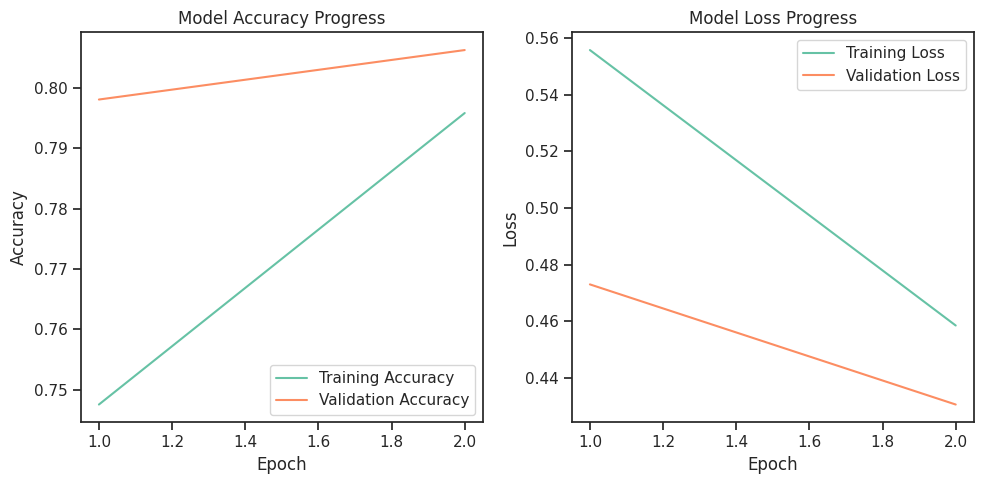

Evaluating DistilBERT Model on Test Dataset
310/310 ━━━━━━━━━━━━━━━━━━━━ 78s 252ms/step - accuracy: 0.7996 - loss: 0.4461
{'loss': 0.4417789578437805, 'compile_metrics': 0.8005445003509521}
310/310 ━━━━━━━━━━━━━━━━━━━━ 84s 262ms/step


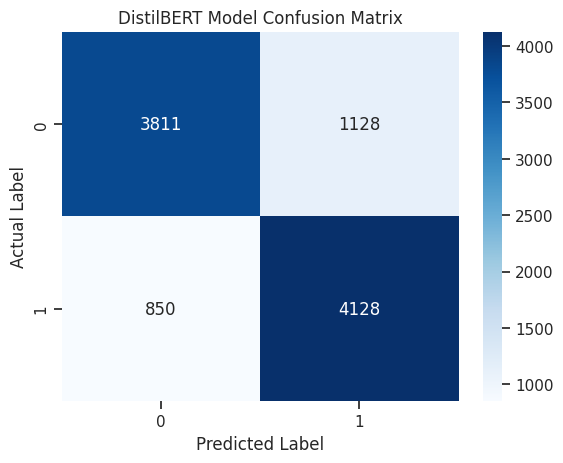

In [ ]:
# Data preparation for transformer model
training_data, testing_data = train_test_split(dataset_copy, test_size=0.2, random_state=42)
X_train_bert, y_train_bert = training_data['review'], training_data['sentiment']
X_test_bert, y_test_bert = testing_data['review'], testing_data['sentiment']

# Create validation split from training data
X_train_final_bert, X_val_bert, y_train_final_bert, y_val_bert = train_test_split(
    X_train_bert, y_train_bert, test_size=0.2, random_state=10)

# Initialize pre-trained tokenizer
distilbert_tokenizer = transformers.AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize and encode text data
train_encoded = distilbert_tokenizer(X_train_final_bert.tolist(), max_length=optimal_length,
                                   truncation=True, padding='max_length',
                                   add_special_tokens=True, return_tensors='np')
val_encoded = distilbert_tokenizer(X_val_bert.tolist(), max_length=optimal_length,
                                 truncation=True, padding='max_length',
                                 add_special_tokens=True, return_tensors='np')
test_encoded = distilbert_tokenizer(X_test_bert.tolist(), max_length=optimal_length,
                                  truncation=True, padding='max_length',
                                  add_special_tokens=True, return_tensors='np')

# Create TensorFlow datasets with proper structure for multiple inputs
bert_train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'token_inputs': train_encoded['input_ids'],
        'mask_inputs': train_encoded['attention_mask']
    },
    y_train_final_bert
))
bert_val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'token_inputs': val_encoded['input_ids'],
        'mask_inputs': val_encoded['attention_mask']
    },
    y_val_bert
))
bert_test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'token_inputs': test_encoded['input_ids'],
        'mask_inputs': test_encoded['attention_mask']
    },
    y_test_bert
))

# Create a custom layer to wrap the DistilBERT model
class DistilBertLayer(tf.keras.layers.Layer):
    def __init__(self, transformer_model, **kwargs):
        super(DistilBertLayer, self).__init__(**kwargs)
        self.transformer_model = transformer_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        # Convert to proper tensor format
        input_ids = tf.cast(input_ids, tf.int32)
        attention_mask = tf.cast(attention_mask, tf.int32)

        outputs = self.transformer_model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs[0]  # Return last hidden state

def create_distilbert_model(train_data, validation_data, transformer_model, sequence_length, training_epochs):
    print("----Constructing DistilBERT model----")

    # Define input layers
    token_inputs = Input(shape=(sequence_length,), dtype=tf.int32, name="token_inputs")
    mask_inputs = Input(shape=(sequence_length,), dtype=tf.int32, name="mask_inputs")

    # Use custom layer to wrap transformer
    distilbert_layer = DistilBertLayer(transformer_model)
    transformer_outputs = distilbert_layer([token_inputs, mask_inputs])

    # Extract CLS token representation
    cls_representation = transformer_outputs[:, 0, :]

    # Add classification layers
    dense_layer = Dense(512, activation='relu')(cls_representation)
    dropout_layer = Dropout(0.1)(dense_layer)
    output_layer = Dense(1, activation='sigmoid')(dropout_layer)

    # Create and compile model
    bert_classifier = Model(inputs=[token_inputs, mask_inputs], outputs=output_layer)
    bert_classifier.summary()
    bert_classifier.compile(Adam(learning_rate=2e-5), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    training_history = bert_classifier.fit(train_data.batch(32), batch_size=32,
                                         validation_data=validation_data.batch(32),
                                         epochs=training_epochs)

    print("Training performance:", bert_classifier.evaluate(train_data.batch(32)))
    print("Validation performance:", bert_classifier.evaluate(validation_data.batch(32)))
    epoch_count = len(training_history.history['loss'])

    return training_history, bert_classifier, epoch_count

# Load pre-trained DistilBERT model
distilbert_model = transformers.TFDistilBertModel.from_pretrained('distilbert-base-uncased')

# Model training configuration
BERT_EPOCHS = 2
sequence_max_length = optimal_length

# Train DistilBERT model
bert_history, trained_bert_model, bert_epoch_count = create_distilbert_model(
    bert_train_dataset, bert_val_dataset, distilbert_model, sequence_max_length, BERT_EPOCHS)

# Visualize training progress
display_training_curves(bert_history, bert_epoch_count)

print("Evaluating DistilBERT Model on Test Dataset")
bert_test_results = trained_bert_model.evaluate(bert_test_dataset.batch(32))
print(dict(zip(trained_bert_model.metrics_names, bert_test_results)))

# Generate predictions and confusion matrix
bert_predictions = trained_bert_model.predict(bert_test_dataset.batch(32))
bert_binary_predictions = bert_predictions > 0.5
bert_confusion_matrix = confusion_matrix(y_test_bert, bert_binary_predictions)
sns.heatmap(bert_confusion_matrix, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('DistilBERT Model Confusion Matrix')
plt.show()